# 06 — Spatial Network Analysis

## Objective

Explore the spatial organization of the European tourism system using a territorial adjacency network.

---

## Data

* Final dataset (Notebook 03)
* NUTS2 regions (2010–2023)
* European territorial geometries

---

## Method

* Spatial adjacency graph construction
* Network centrality measures
* Community detection (Louvain algorithm)
* Correlation between tourism and network structure

---

## Output

* Spatial connectivity indicators
* Betweenness centrality map
* Territorial community structure
* Tourism and centrality relationships

---


In [34]:
# ============================================================
# 06_network_analysis.ipynb
# Spatial Network Structure of European Tourism Systems
# ============================================================

# ============================================================
# Imports
# ============================================================
import pandas as pd
import geopandas as gpd
import numpy as np

import networkx as nx

import matplotlib.pyplot as plt

import community as community_louvain

In [6]:
# ============================================================
# Load harmonized panel dataset
# ============================================================

df = pd.read_csv("../data/processed/final_dataset_nuts2_2010_2023.csv")

df.head()

,region,year,tourism_nights,gdp,population,temperature,precipitation
0,AL01,2018.0,199081.0,2939.04,819793.0,12.073321,1041.8892
1,AL01,2019.0,259910.0,3121.44,813758.0,11.967571,891.8104
2,AL01,2020.0,148755.0,2907.94,804689.0,11.721833,865.5977
3,AL01,2021.0,206227.0,3389.55,797955.0,11.205980,1087.7075
4,AL01,2022.0,261012.0,4088.34,783970.0,11.735918,948.7667


## Regional aggregation

The network analysis is performed at the NUTS2 level.
Because the objective is to study the spatial structure
of tourism systems rather than yearly fluctuations,
variables are aggregated at the regional level.

Average tourism and climate conditions are computed
across the 2010–2023 period.

In [8]:
print(df.columns.tolist())

['region', 'year', 'tourism_nights', 'gdp', 'population', 'temperature', 'precipitation']


In [35]:
# ============================================================
# Regional averages
# ============================================================

df["log_tourism"] = np.log(df["tourism_nights"] + 1)

regional_df = (
    df.groupby("region")
    .agg(
        log_tourism_mean=("log_tourism", "mean"),
        temperature_mean=("temperature", "mean"),
        precipitation_mean=("precipitation", "mean"),
        gdp_mean=("gdp", "mean"),
        population_mean=("population", "mean")
    )
    .reset_index()
)

regional_df = regional_df.round(3)

regional_df.head()

,region,log_tourism_mean,temperature_mean,precipitation_mean,gdp_mean,population_mean
0,AL01,12.391,11.810,979.241,3555.700,798530.833
1,AL02,12.601,13.454,283.034,7963.342,1173995.167
2,AL03,13.176,14.488,934.189,4373.615,854778.000
3,AT11,14.014,11.421,220.332,8477.513,291061.643
4,AT12,14.745,9.813,1098.768,57523.550,1655047.857


In [15]:
# ============================================================
# Load NUTS2 geometries
# ============================================================

nuts = gpd.read_file(
    "../data/raw/NUTS_RG_01M_2021_4326/NUTS_RG_01M_2021_4326.shp"
)

# ============================================================
# Keep NUTS2 regions only
# ============================================================

nuts = nuts[nuts["LEVL_CODE"] == 2]

nuts = nuts.rename(columns={"NUTS_ID": "region"})

nuts = nuts[["region", "geometry"]]

nuts.head()

,region,geometry
104,DE12,"MULTIPOLYGON (((9.45238 49.64864, 9.47674 49.6..."
105,CH05,"MULTIPOLYGON (((8.57249 47.80563, 8.57657 47.8..."
106,CZ02,"MULTIPOLYGON (((14.93193 50.60686, 14.93977 50..."
111,CH01,"MULTIPOLYGON (((6.73967 46.89227, 6.73801 46.8..."
112,BE24,"POLYGON ((5.1597 51.02415, 5.13283 51.01607, 5..."


In [36]:
# ============================================================
# Merge spatial indicators
# ============================================================

gdf = nuts.merge(
    regional_df,
    on="region",
    how="inner"
)

gdf = gdf.to_crs(epsg=3035)

gdf.head()

,region,geometry,log_tourism_mean,temperature_mean,precipitation_mean,gdp_mean,population_mean
0,DE12,"MULTIPOLYGON (((4281446.787 2948583.656, 42832...",15.415,10.566,522.427,122003.351,2756539.000
1,CH05,"MULTIPOLYGON (((4214016.748 2744590.195, 42143...",15.253,4.553,1113.684,74194.420,1147785.750
2,CZ02,"MULTIPOLYGON (((4669840.056 3066760.71, 467040...",13.818,9.785,456.512,23992.585,1333788.643
3,CH01,"MULTIPOLYGON (((4072402.904 2647551.331, 40722...",15.273,4.667,811.151,113211.837,1576667.083
4,BE24,"POLYGON ((3981678.385 3112663.404, 3979738.831...",13.312,11.176,190.423,48488.766,1129137.786


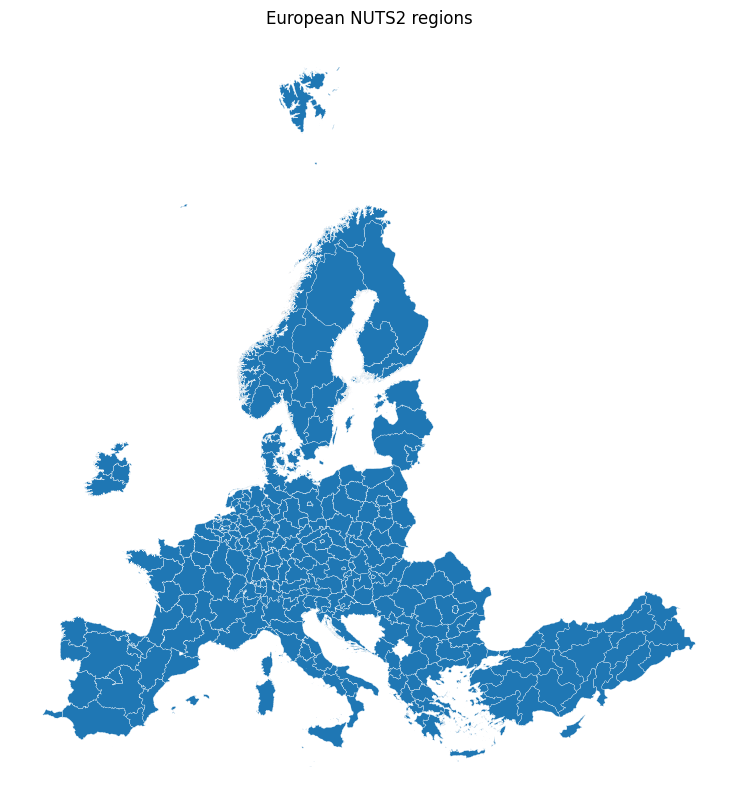

In [37]:
# ============================================================
# NUTS2 regions
# ============================================================

fig, ax = plt.subplots(figsize=(10, 10))

gdf.plot(
    ax=ax,
    linewidth=0.2,
    edgecolor="white"
)

ax.set_title("European NUTS2 regions")

ax.axis("off")

plt.show()

In [18]:
# ============================================================
# Spatial adjacency graph
# ============================================================

G = nx.Graph()

# Add nodes
for idx, row in gdf.iterrows():

    G.add_node(
        row["region"],
        tourism=row["log_tourism_mean"],
        temperature=row["temperature_mean"],
        precipitation=row["precipitation_mean"],
        gdp=row["gdp_mean"],
        population=row["population_mean"]
    )

# Add edges based on shared borders
for i, row_i in gdf.iterrows():

    for j, row_j in gdf.iterrows():

        if i >= j:
            continue

        if row_i.geometry.touches(row_j.geometry):

            G.add_edge(
                row_i["region"],
                row_j["region"]
            )

print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

Number of nodes: 273
Number of edges: 621


In [19]:
# ============================================================
# Basic network statistics
# ============================================================

density = nx.density(G)

components = nx.number_connected_components(G)

avg_degree = np.mean([d for n, d in G.degree()])

print("Network density:", round(density, 4))
print("Connected components:", components)
print("Average degree:", round(avg_degree, 2))

Network density: 0.0167
Connected components: 15
Average degree: 4.55


The spatial network exhibits a sparse structure,
which is expected for a territorial adjacency graph.

The presence of multiple connected components is mainly
explained by islands and geographically isolated regions,
which do not share direct land borders with the continental system.

In [20]:
# ============================================================
# Centrality measures
# ============================================================

degree_centrality = nx.degree_centrality(G)

closeness_centrality = nx.closeness_centrality(G)

betweenness_centrality = nx.betweenness_centrality(G)

In [21]:
# ============================================================
# Add centrality measures
# ============================================================

gdf["degree_centrality"] = gdf["region"].map(degree_centrality)

gdf["closeness_centrality"] = gdf["region"].map(closeness_centrality)

gdf["betweenness_centrality"] = gdf["region"].map(betweenness_centrality)

In [22]:
# ============================================================
# Top regions by betweenness centrality
# ============================================================

top_regions = (
    gdf[
        [
            "region",
            "betweenness_centrality",
            "log_tourism_mean",
            "temperature_mean"
        ]
    ]
    .sort_values("betweenness_centrality", ascending=False)
    .head(10)
)

top_regions.round(3)

,region,betweenness_centrality,log_tourism_mean,temperature_mean
39,AT21,0.199,14.919,6.661
231,SI03,0.189,14.098,10.844
117,RS22,0.180,13.301,11.294
110,RS12,0.158,12.903,13.242
191,HR02,0.150,12.019,12.763
260,TR21,0.145,13.670,15.098
164,ITH3,0.144,16.240,12.438
209,ITC1,0.113,15.278,10.548
183,SK02,0.112,13.875,10.738
184,FRK2,0.108,16.417,10.364


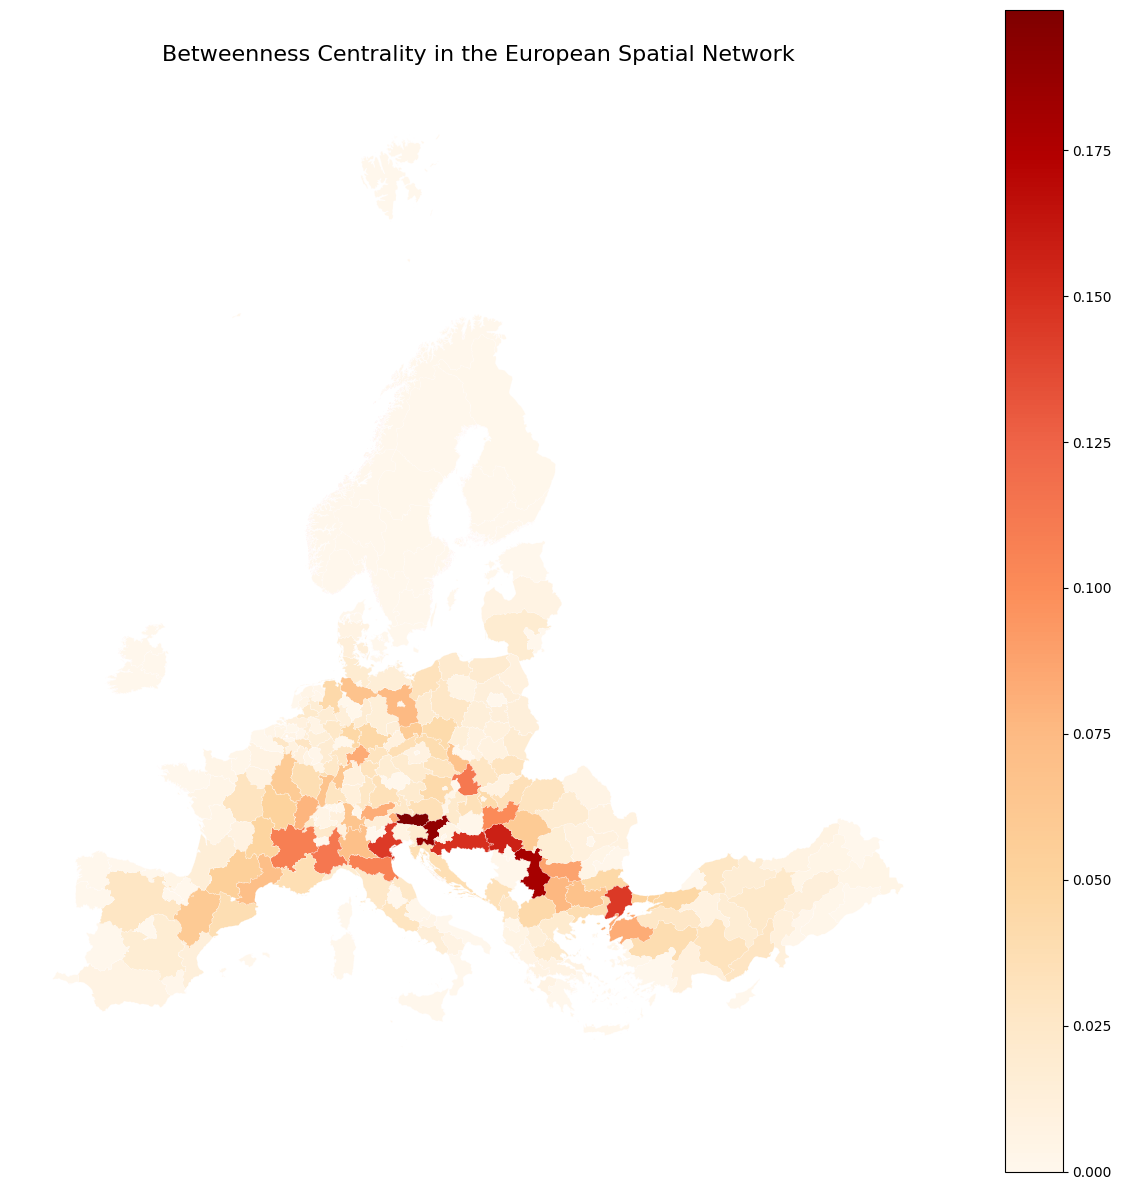

In [24]:
fig, ax = plt.subplots(figsize=(12, 12))

gdf.plot(
    column="betweenness_centrality",
    cmap="OrRd",
    linewidth=0.15,
    edgecolor="white",
    legend=True,
    ax=ax
)

ax.set_title(
    "Betweenness Centrality in the European Spatial Network",
    fontsize=16,
    pad=20
)

ax.axis("off")

plt.tight_layout()

plt.show()

Regions with high betweenness centrality occupy structurally
important intermediary positions within the European spatial system.

These regions often correspond to territorial corridors
or transition areas connecting multiple European macro-regions.

In [30]:
# ============================================================
# Community detection (Louvain)
# ============================================================

partition = community_louvain.best_partition(G)

gdf["community"] = gdf["region"].map(partition)

print("Number of communities:", gdf["community"].nunique())

Number of communities: 23


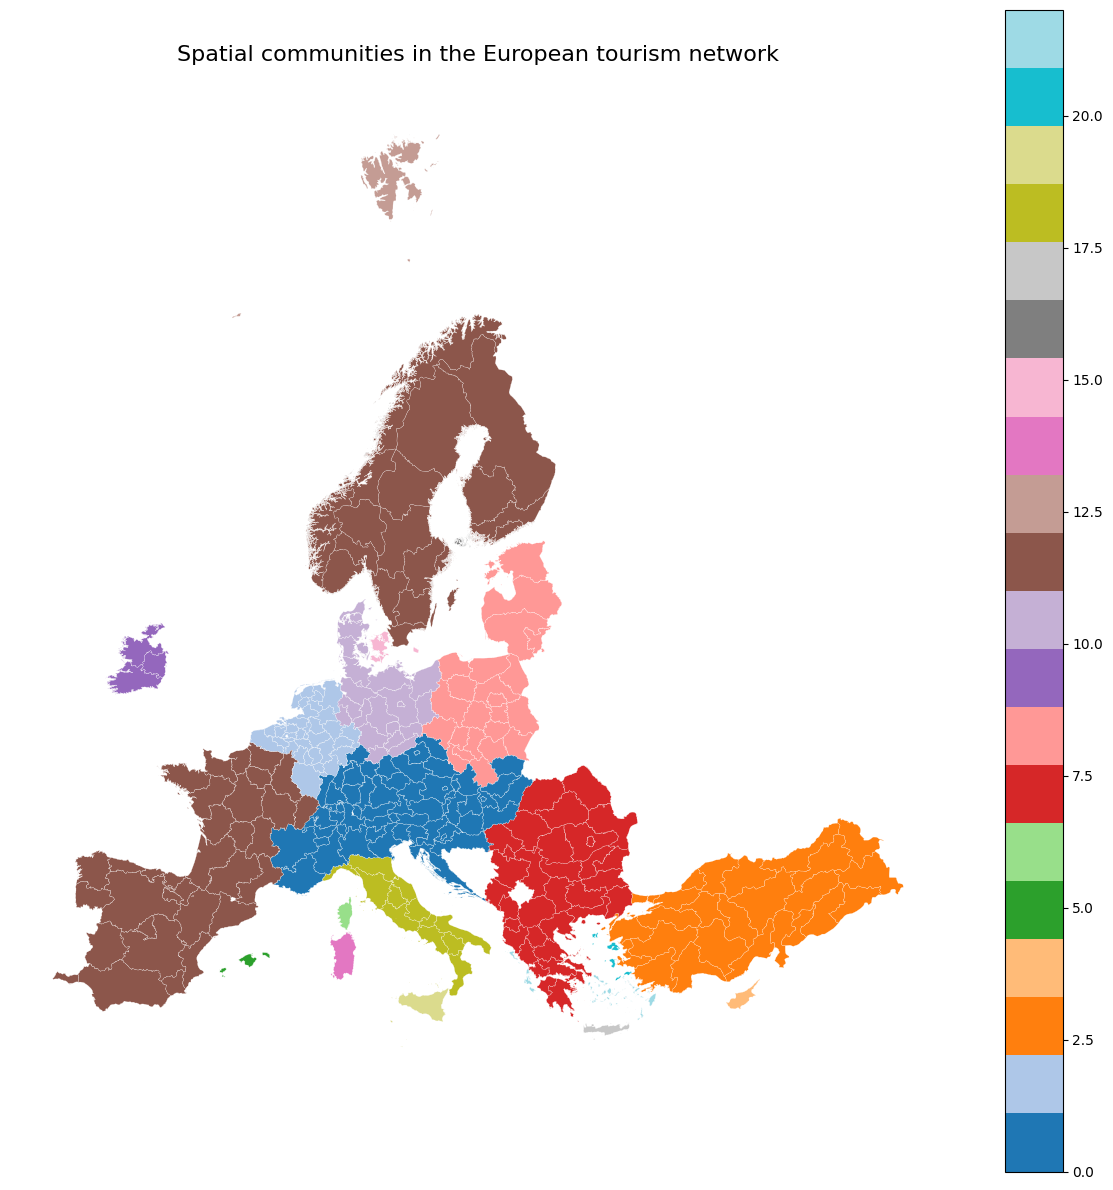

In [31]:
# ============================================================
# Community map
# ============================================================

fig, ax = plt.subplots(figsize=(12, 12))

gdf.plot(
    column="community",
    cmap="tab20",
    linewidth=0.15,
    edgecolor="white",
    legend=True,
    ax=ax
)

ax.set_title(
    "Spatial communities in the European tourism network",
    fontsize=16,
    pad=20
)

ax.axis("off")

plt.tight_layout()

plt.show()

In [32]:
# ============================================================
# Correlation analysis
# ============================================================

corr = gdf[
    [
        "log_tourism_mean",
        "degree_centrality",
        "closeness_centrality",
        "betweenness_centrality"
    ]
].corr()

corr.round(3)

,log_tourism_mean,degree_centrality,closeness_centrality,betweenness_centrality
log_tourism_mean,1.000,0.101,0.105,0.088
degree_centrality,0.101,1.000,0.623,0.564
closeness_centrality,0.105,0.623,1.000,0.424
betweenness_centrality,0.088,0.564,0.424,1.000


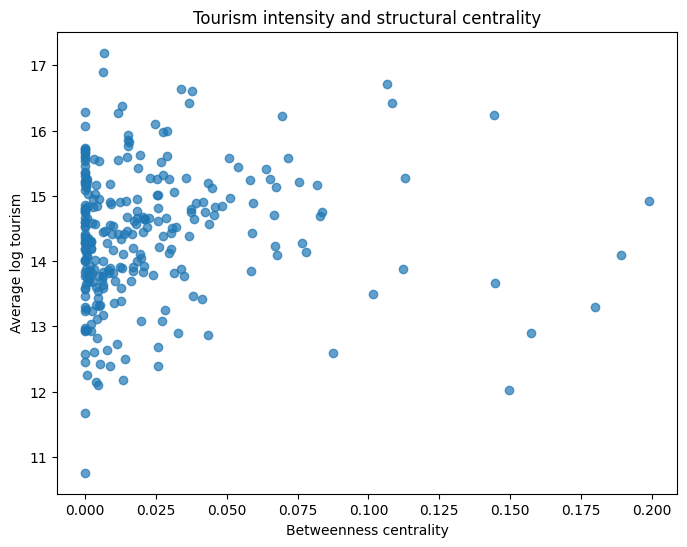

In [33]:
# ============================================================
# Tourism and betweenness centrality
# ============================================================

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    gdf["betweenness_centrality"],
    gdf["log_tourism_mean"],
    alpha=0.7
)

ax.set_xlabel("Betweenness centrality")
ax.set_ylabel("Average log tourism")

ax.set_title(
    "Tourism intensity and structural centrality"
)

plt.show()